In [80]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

rental_data = pd.read_csv('data/Gh_house_rentals.csv')

#select first five rows to inspect
rental_data.head()

,url,listing_type,name,price,category,bedrooms,bathrooms,floor_area,location,condition,amenities,region,locality,parking_space,is_furnished,lat,lng
0,https://tonaton.com/a-MfYFNdCgCTytOcmvZIh0Kzrj...,rentals,"2bdrm Apartment in Charclem Ventures, East Leg...",9196.0,Flats,2,2,145.0,"Greater Accra, East Legon",Used,"24-hour Electricity,Air Conditioning,Balcony,C...",Greater Accra,East Legon,False,Semi-Furnished,5.635828,-0.161359
1,https://tonaton.com/a-MfYFNdCgwtb8Itol9odpMPvC...,rentals,"2bdrm Apartment in , Dzorwulu for rent",7500.0,Flats,2,2,100.0,"Greater Accra, Dzorwulu",Used,"24-hour Electricity,Air Conditioning,Apartment...",Greater Accra,Dzorwulu,False,Unfurnished,5.614123,-0.195647
2,https://tonaton.com/a-MfYFNdCgPjnzPYwNFEv5JrGy...,rentals,"4bdrm House in Lakeside Estate, for Rent",11200.0,Detached,4,5,100.0,"Greater Accra, Ashaley Botwe, Lake Side Estate",New,"Tiled Floor,Chandelier,Dining Area,Balcony,Pop...",Greater Accra,Ashaley Botwe,False,Semi-Furnished,5.680213,-0.137248
3,https://tonaton.com/a-MfYFNdCgwmXHQRNJiSR3rok8...,rentals,"3bdrm House in Ayathar Bedroom, Teshie for Rent",2500.0,Detached,3,3,17.0,"Greater Accra, Teshie",Used,"Pop Ceiling,Pre-Paid Meter,24-hour Electricity...",Greater Accra,Teshie,False,Semi-Furnished,5.583166,-0.104608
4,https://tonaton.com/a-MfYFNdCgn3Bcs511lKnFE19i...,rentals,"3bdrm House in Manet Viile Estate, Spintex for...",9146.0,Detached,3,3,160.0,"Greater Accra, Spintex",Used,"Pre-Paid Meter,Dining Area,Chandelier,Balcony,...",Greater Accra,Spintex,False,Semi-Furnished,5.637614,-0.126606


In [81]:
#information on data frame

rental_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 18263 entries, 0 to 18262
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   url            18263 non-null  str    
 1   listing_type   18263 non-null  str    
 2   name           18222 non-null  str    
 3   price          18199 non-null  float64
 4   category       18263 non-null  str    
 5   bedrooms       18263 non-null  int64  
 6   bathrooms      18263 non-null  int64  
 7   floor_area     18221 non-null  float64
 8   location       18263 non-null  str    
 9   condition      18263 non-null  str    
 10  amenities      18195 non-null  str    
 11  region         18263 non-null  str    
 12  locality       18263 non-null  str    
 13  parking_space  18263 non-null  bool   
 14  is_furnished   18263 non-null  str    
 15  lat            18263 non-null  float64
 16  lng            18263 non-null  float64
dtypes: bool(1), float64(4), int64(2), str(10)
memory usage: 2.2 M

In [82]:
#checking for null values accross dataframe

rental_data.isnull().sum()

url               0
listing_type      0
name             41
price            64
category          0
bedrooms          0
bathrooms         0
floor_area       42
location          0
condition         0
amenities        68
region            0
locality          0
parking_space     0
is_furnished      0
lat               0
lng               0
dtype: int64

In [83]:
#we need to check the impact of the missing data to our entire data
#return a series of indexes as names of columns and values as their mean
(rental_data.isnull().mean() * 100).round(2)

url              0.00
listing_type     0.00
name             0.22
price            0.35
category         0.00
bedrooms         0.00
bathrooms        0.00
floor_area       0.23
location         0.00
condition        0.00
amenities        0.37
region           0.00
locality         0.00
parking_space    0.00
is_furnished     0.00
lat              0.00
lng              0.00
dtype: float64

In [84]:
#Any mean under 1-2% is considered safe to drop or lightly impute
#drop price since it's 0.35% and will not hurt the dataset
#dropping less than 1% won't hurt data

rental_data = rental_data.dropna(subset=['price'])

#floor area, impute with median

rental_data['floor_area'].fillna(rental_data['floor_area'].median(), inplace=True)

#treat missing values for amenities
#treat missing as no amenities
rental_data['amenities'].fillna('None', inplace=True)

#impute name since it's 0.22%
#treat missing name as an unknown listing
rental_data['name'].fillna('Unknown listing', inplace=True)

rental_data.head()


,url,listing_type,name,price,category,bedrooms,bathrooms,floor_area,location,condition,amenities,region,locality,parking_space,is_furnished,lat,lng
0,https://tonaton.com/a-MfYFNdCgCTytOcmvZIh0Kzrj...,rentals,"2bdrm Apartment in Charclem Ventures, East Leg...",9196.0,Flats,2,2,145.0,"Greater Accra, East Legon",Used,"24-hour Electricity,Air Conditioning,Balcony,C...",Greater Accra,East Legon,False,Semi-Furnished,5.635828,-0.161359
1,https://tonaton.com/a-MfYFNdCgwtb8Itol9odpMPvC...,rentals,"2bdrm Apartment in , Dzorwulu for rent",7500.0,Flats,2,2,100.0,"Greater Accra, Dzorwulu",Used,"24-hour Electricity,Air Conditioning,Apartment...",Greater Accra,Dzorwulu,False,Unfurnished,5.614123,-0.195647
2,https://tonaton.com/a-MfYFNdCgPjnzPYwNFEv5JrGy...,rentals,"4bdrm House in Lakeside Estate, for Rent",11200.0,Detached,4,5,100.0,"Greater Accra, Ashaley Botwe, Lake Side Estate",New,"Tiled Floor,Chandelier,Dining Area,Balcony,Pop...",Greater Accra,Ashaley Botwe,False,Semi-Furnished,5.680213,-0.137248
3,https://tonaton.com/a-MfYFNdCgwmXHQRNJiSR3rok8...,rentals,"3bdrm House in Ayathar Bedroom, Teshie for Rent",2500.0,Detached,3,3,17.0,"Greater Accra, Teshie",Used,"Pop Ceiling,Pre-Paid Meter,24-hour Electricity...",Greater Accra,Teshie,False,Semi-Furnished,5.583166,-0.104608
4,https://tonaton.com/a-MfYFNdCgn3Bcs511lKnFE19i...,rentals,"3bdrm House in Manet Viile Estate, Spintex for...",9146.0,Detached,3,3,160.0,"Greater Accra, Spintex",Used,"Pre-Paid Meter,Dining Area,Chandelier,Balcony,...",Greater Accra,Spintex,False,Semi-Furnished,5.637614,-0.126606


In [85]:
#dealing with duplicates

#total duplicated rows
rental_data.duplicated().sum()

#removing all duplicates
rental_data = rental_data.drop_duplicates()



In [86]:

#dealing with incosistencies in variables
#is_furnished
#incosistencies almost always lie in the columns with the object type

rental_data['is_furnished'].value_counts()


is_furnished
Unfurnished       10364
Semi-Furnished     5308
Furnished          2332
Name: count, dtype: int64

In [87]:
#fix all columns incosistencies

cols = ['condition', 'region', 'locality', 'location']

for col in cols:
    rental_data[col] = rental_data[col].str.strip().str.title()


In [88]:
rental_data['locality'].value_counts()

locality
East Legon            2574
Spintex               1816
Teshie                1341
Adenta                1266
Accra Metropolitan    1039
                      ... 
Nii Boi Town             1
Asuogyaman               1
Little Legon             1
Lartebiokorshie          1
Bubuashie                1
Name: count, Length: 107, dtype: int64

In [89]:
#convert categorical columsn to numeric

furnished_map = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2}

rental_data['is_furnished'] = rental_data['is_furnished'].map(furnished_map)

category_dums = pd.get_dummies(rental_data['category'], prefix='category', drop_first=False)

condition_dums = pd.get_dummies(rental_data['condition'], prefix='condition', drop_first=False)

rental_data = pd.concat([rental_data, category_dums], axis=1)

rental_data = pd.concat([rental_data, condition_dums], axis=1)

rental_data.head()

,url,listing_type,name,price,category,bedrooms,bathrooms,floor_area,location,condition,...,lng,category_Detached,category_Duplex,category_Flats,category_Mansion,category_Semi-Detached,category_Townhouse,condition_New,condition_Renovated,condition_Used
0,https://tonaton.com/a-MfYFNdCgCTytOcmvZIh0Kzrj...,rentals,"2bdrm Apartment in Charclem Ventures, East Leg...",9196.0,Flats,2,2,145.0,"Greater Accra, East Legon",Used,...,-0.161359,False,False,True,False,False,False,False,False,True
1,https://tonaton.com/a-MfYFNdCgwtb8Itol9odpMPvC...,rentals,"2bdrm Apartment in , Dzorwulu for rent",7500.0,Flats,2,2,100.0,"Greater Accra, Dzorwulu",Used,...,-0.195647,False,False,True,False,False,False,False,False,True
2,https://tonaton.com/a-MfYFNdCgPjnzPYwNFEv5JrGy...,rentals,"4bdrm House in Lakeside Estate, for Rent",11200.0,Detached,4,5,100.0,"Greater Accra, Ashaley Botwe, Lake Side Estate",New,...,-0.137248,True,False,False,False,False,False,True,False,False
3,https://tonaton.com/a-MfYFNdCgwmXHQRNJiSR3rok8...,rentals,"3bdrm House in Ayathar Bedroom, Teshie for Rent",2500.0,Detached,3,3,17.0,"Greater Accra, Teshie",Used,...,-0.104608,True,False,False,False,False,False,False,False,True
4,https://tonaton.com/a-MfYFNdCgn3Bcs511lKnFE19i...,rentals,"3bdrm House in Manet Viile Estate, Spintex for...",9146.0,Detached,3,3,160.0,"Greater Accra, Spintex",Used,...,-0.126606,True,False,False,False,False,False,False,False,True


In [90]:
#convert parking space from boolean to numeric
cols_to_int = ['parking_space', 'category_Detached', 'category_Duplex', 'category_Flats', 'category_Mansion', 'category_Semi-Detached', 'category_Townhouse', 'condition_New', 'condition_Renovated', 'condition_Used']
rental_data[cols_to_int] = rental_data[cols_to_int].astype(int)

rental_data.head()

,url,listing_type,name,price,category,bedrooms,bathrooms,floor_area,location,condition,...,lng,category_Detached,category_Duplex,category_Flats,category_Mansion,category_Semi-Detached,category_Townhouse,condition_New,condition_Renovated,condition_Used
0,https://tonaton.com/a-MfYFNdCgCTytOcmvZIh0Kzrj...,rentals,"2bdrm Apartment in Charclem Ventures, East Leg...",9196.0,Flats,2,2,145.0,"Greater Accra, East Legon",Used,...,-0.161359,0,0,1,0,0,0,0,0,1
1,https://tonaton.com/a-MfYFNdCgwtb8Itol9odpMPvC...,rentals,"2bdrm Apartment in , Dzorwulu for rent",7500.0,Flats,2,2,100.0,"Greater Accra, Dzorwulu",Used,...,-0.195647,0,0,1,0,0,0,0,0,1
2,https://tonaton.com/a-MfYFNdCgPjnzPYwNFEv5JrGy...,rentals,"4bdrm House in Lakeside Estate, for Rent",11200.0,Detached,4,5,100.0,"Greater Accra, Ashaley Botwe, Lake Side Estate",New,...,-0.137248,1,0,0,0,0,0,1,0,0
3,https://tonaton.com/a-MfYFNdCgwmXHQRNJiSR3rok8...,rentals,"3bdrm House in Ayathar Bedroom, Teshie for Rent",2500.0,Detached,3,3,17.0,"Greater Accra, Teshie",Used,...,-0.104608,1,0,0,0,0,0,0,0,1
4,https://tonaton.com/a-MfYFNdCgn3Bcs511lKnFE19i...,rentals,"3bdrm House in Manet Viile Estate, Spintex for...",9146.0,Detached,3,3,160.0,"Greater Accra, Spintex",Used,...,-0.126606,1,0,0,0,0,0,0,0,1


In [91]:

sampled_data = rental_data.sample(n=7000, random_state=22430699).reset_index(drop=True)

sampled_data.drop(columns=['condition', 'category'], inplace=True)

sampled_data.to_csv('Gh_rentals_sampled.csv')

## Descriptive Analysis


In [92]:
#Descriptive statistics for the the sampled data

sampl_data = pd.read_csv('Gh_rentals_sampled.csv')

#select all numerical columns

numeric_columns = ['bedrooms', 'price','bathrooms', 'floor_area', 'lat', 'parking_space', 'lng']
desc_data = sampl_data[numeric_columns].describe()

#checking for skewness, kurtosis
for col in numeric_columns:
    print(f'\n{col}')
    print(f'Skewness : {sampl_data[col].skew():.3f}')
    print(f'Kurtosis : {sampl_data[col].kurtosis():.3f}')
    
print(desc_data)

print('\n --- CATEGORICAL VARIABLES ---')
categorical_columns = ['listing_type', 'region', 'locality', 'is_furnished', 'category_Detached', 
                   'category_Duplex', 'category_Flats', 'category_Mansion', 'category_Semi-Detached',
                   'category_Townhouse', 'condition_New', 'condition_Renovated', 'condition_Used']

#select all categorical data
#reconstruct from one encoding
sampl_data['condition'] = sampl_data[['condition_New', 'condition_Renovated', 'condition_Used']].idxmax(axis=1).str.replace('condition_', '')
sampl_data['category'] = sampl_data[['category_Detached', 'category_Duplex', 'category_Flats', 
                      'category_Mansion', 'category_Semi-Detached', 'category_Townhouse']].idxmax(axis=1).str.replace('category_', '')


print('\nCondition Distribution')
print(sampl_data['condition'].value_counts())

print('\nCategory Distribution')
print(sampl_data['category'].value_counts())

print('\nRegion Distribution')
print(sampl_data['region'].value_counts())

print('\nFurnishing Status Distribution')
print(sampl_data['is_furnished'].value_counts())


bedrooms
Skewness : 1.576
Kurtosis : 8.395

price
Skewness : 2.357
Kurtosis : 5.851

bathrooms
Skewness : 1.243
Kurtosis : 5.369

floor_area
Skewness : 3.238
Kurtosis : 10.328

lat
Skewness : 6.465
Kurtosis : 47.538

parking_space
Skewness : 41.806
Kurtosis : 1746.248

lng
Skewness : -3.856
Kurtosis : 14.833
          bedrooms         price    bathrooms   floor_area          lat  \
count  7000.000000   7000.000000  7000.000000  6982.000000  7000.000000   
mean      2.448429   7797.571000     2.545857   558.638642     5.726522   
std       1.257490  10170.393423     1.374002  1048.783892     0.449966   
min       1.000000    416.000000     1.000000    10.000000     4.849041   
25%       2.000000   1700.000000     1.000000   100.000000     5.603388   
50%       2.000000   3500.000000     2.000000   140.000000     5.637614   
75%       3.000000   9464.750000     3.000000   600.000000     5.682581   
max      20.000000  59267.000000    20.000000  5000.000000     9.410999   

       parkin

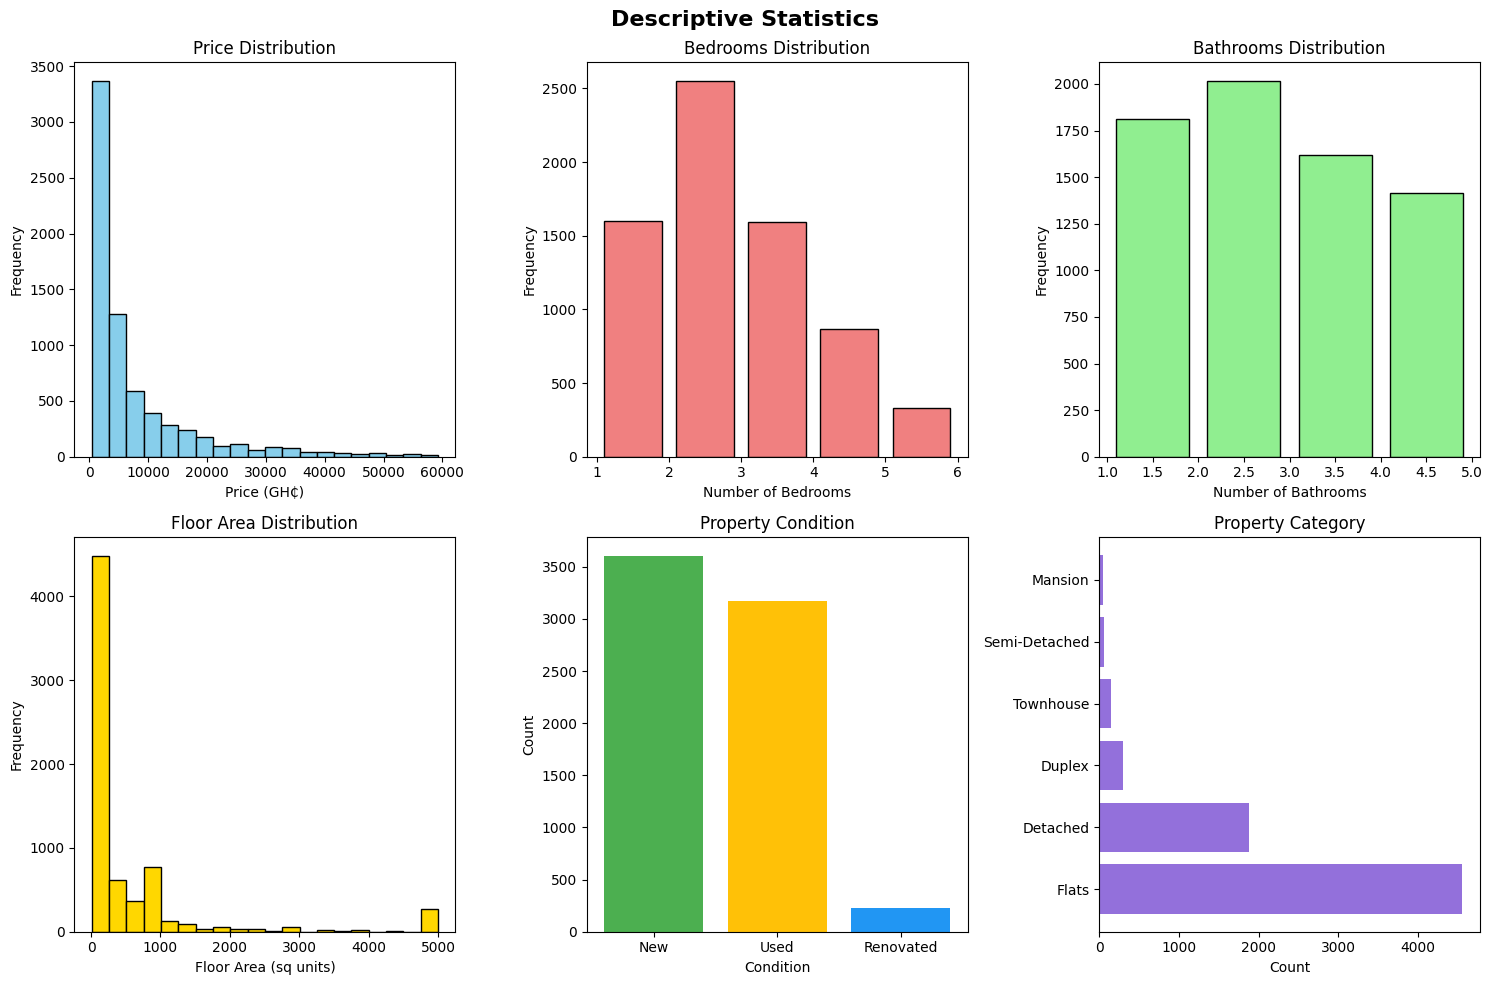

In [93]:
#Visualising the descriptive statistics
import seaborn as sns
import matplotlib.pyplot as plt

#visualizing 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Descriptive Statistics', fontsize=16, fontweight='bold')

# Price distribution
axes[0, 0].hist(sampl_data['price'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (GH₵)')
axes[0, 0].set_ylabel('Frequency')

# Bedrooms
axes[0, 1].hist(sampl_data['bedrooms'], bins=range(1, 7), color='lightcoral', edgecolor='black', rwidth=0.8)
axes[0, 1].set_title('Bedrooms Distribution')
axes[0, 1].set_xlabel('Number of Bedrooms')
axes[0, 1].set_ylabel('Frequency')

# Bathrooms
axes[0, 2].hist(sampl_data['bathrooms'], bins=range(1, 6), color='lightgreen', edgecolor='black', rwidth=0.8)
axes[0, 2].set_title('Bathrooms Distribution')
axes[0, 2].set_xlabel('Number of Bathrooms')
axes[0, 2].set_ylabel('Frequency')

# Floor area
axes[1, 0].hist(sampl_data['floor_area'], bins=20, color='gold', edgecolor='black')
axes[1, 0].set_title('Floor Area Distribution')
axes[1, 0].set_xlabel('Floor Area (sq units)')
axes[1, 0].set_ylabel('Frequency')

# Condition
condition_counts = sampl_data['condition'].value_counts()
axes[1, 1].bar(condition_counts.index, condition_counts.values, color=['#4CAF50', '#FFC107', '#2196F3'])
axes[1, 1].set_title('Property Condition')
axes[1, 1].set_xlabel('Condition')
axes[1, 1].set_ylabel('Count')

# Category
category_counts = sampl_data['category'].value_counts()
axes[1, 2].barh(category_counts.index, category_counts.values, color='mediumpurple')
axes[1, 2].set_title('Property Category')
axes[1, 2].set_xlabel('Count')

plt.tight_layout()
#plt.savefig('descriptive_statistics.png', dpi=300, bbox_inches='tight')





## Descriptive Analysis Interpretation

### Research Question
What are the basic distributional characteristics of the dataset?

The numeric summaries and plots above use **univariate descriptive statistics** (mean, median, skewness, kurtosis) and **histograms/bar charts** to understand the distribution of key rental features. Key takeaways:

- **Price** is right-skewed (long tail toward higher rents), indicating a few expensive listings pull the mean above the median.
- **Bedrooms/bathrooms** are concentrated in the lower count ranges, suggesting most listings are smaller units.
- **Floor area** also shows a right-skewed distribution, consistent with a few large properties.

- For categorical variables, **condition** and **category** show the most common listing types, and the **furnishing status** distribution reveals whether most listings are unfurnished or equipped.This section sets a baseline for later inferential analyses by highlighting the central tendencies, dispersion, and potential outliers in the dataset. The histograms and bar charts above act as a reference for later comparative analyses.


## Research Objective 1: Key Determinants of Rental Prices

### Research Question
What are the key factors that drive rental price, controlling for other variables?

This analysis uses **multivariate linear regression** (after standardizing predictors) to estimate how each feature influences rental price while holding others constant. The coefficient plot (`Feature Importance (Regression Coefficients)`) shows:

- Positive coefficients (green) indicate features associated with higher prices (e.g., larger floor area, more bedrooms).
- Negative coefficients (red) indicate factors associated with lower prices.

- The magnitude of each standardized coefficient reflects relative importance.✅ **Statistical method:** Standardized **Linear Regression** (OLS).



Regression Coefficients
                  Features  Coefficient
1                bathrooms  3210.372131
3             is_furnished  3078.594498
0                 bedrooms  1147.214122
5            condition_New   -23.605790
4            parking_space   -81.787283
6      condition_Renovated  -177.727434
2               floor_area  -330.387708
10        category_Mansion  -526.055456
11  category_Semi-Detached -1149.061824
8          category_Duplex -2121.789286
7        category_Detached -4435.719020
9           category_Flats -5700.440420


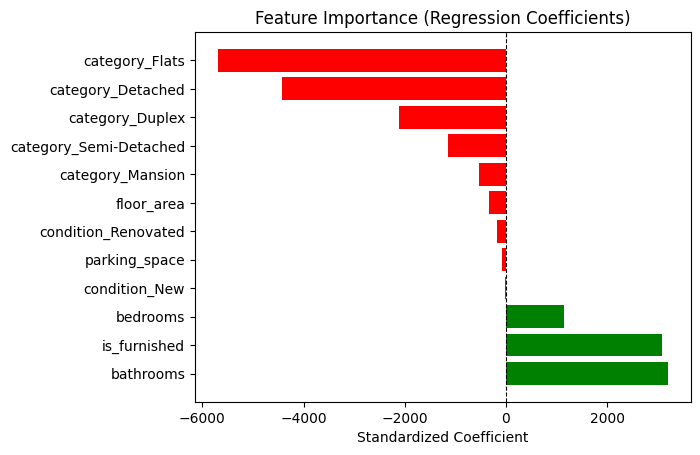

In [94]:
#Research Objective 1, Price determinants
#Multilinear regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
#selecting numeric columns for analysis

num_cols = ['bedrooms', 'bathrooms', 'floor_area', 'is_furnished', 'parking_space',
                'condition_New', 'condition_Renovated', 
                'category_Detached', 'category_Duplex', 'category_Flats', 
                'category_Mansion', 'category_Semi-Detached']

#creating a copy of the data
X = sampl_data[num_cols].copy()
Y = sampl_data['price'].copy()

# handle missing values in predictor variables
X = X.fillna(X.median())

#defining the scaler standardise the values to prevent model from putting emphasis on other values compared to other/ bias
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#create a new data frame from the scaled x values

X_scaled_dataframe = pd.DataFrame(X_scaled, columns=num_cols)

#fitting the model to determine model parameters/coeffecients

linear_regression = LinearRegression()

linear_regression.fit(X_scaled_dataframe, Y)

#coeff's represent the impact of the variables on the price
print('\nRegression Coefficients')
reg_coef_dataframe = pd.DataFrame({
    'Features': num_cols,
    'Coefficient': linear_regression.coef_
}).sort_values('Coefficient', ascending=False)

print(reg_coef_dataframe)

#predictions
y_prediction = linear_regression.predict(X_scaled_dataframe)
rmse = np.sqrt(mean_squared_error(Y, y_prediction))
mae = mean_absolute_error(Y, y_prediction)

#visualizations


# Coefficient plot
plt.barh(reg_coef_dataframe['Features'], reg_coef_dataframe['Coefficient'], 
                color=['green' if x > 0 else 'red' for x in reg_coef_dataframe['Coefficient']])
plt.xlabel('Standardized Coefficient')
plt.title('Feature Importance (Regression Coefficients)')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

## Research Objective 2: Property Category & Condition Effects

### Research Question
How do property category and condition affect rental prices, and is there an interaction between them?

We use a **two-way ANOVA** to test whether mean rental price differs by **property category**, **condition**, and their interaction. The Tukey HSD post-hoc test compares specific group pairs.

The plots show:

- **Boxplot (Price Distribution by Category and Condition):** How price distributions vary across categories and conditions.

- **Interaction plot (Category × Condition):** Whether the effect of condition on price depends on category (non-parallel lines suggest interaction).

**Statistical method:** **Two-way ANOVA** with **Tukey HSD** post-hoc comparisons.


                                sum_sq      df           F         PR(>F)
C(condition)              2.439874e+09     2.0   14.371864   5.904613e-07
C(category)               1.276824e+11     5.0  300.840804  1.818424e-292
C(condition):C(category)  2.033494e+09    10.0    2.395624   7.791270e-03
Residual                  5.926579e+11  6982.0         NaN            NaN

Post-hoc Tests (Tukey HSD):

--- Condition ---
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
  group1    group2   meandiff  p-adj    lower      upper   reject
-----------------------------------------------------------------
      New Renovated -2721.2153 0.0003 -4354.5536 -1087.877   True
      New      Used  -220.9173 0.6448  -800.8961  359.0616  False
Renovated      Used   2500.298  0.001    860.406   4140.19   True
-----------------------------------------------------------------

✓ ANOVA analysis saved as 'objective2_anova.png'


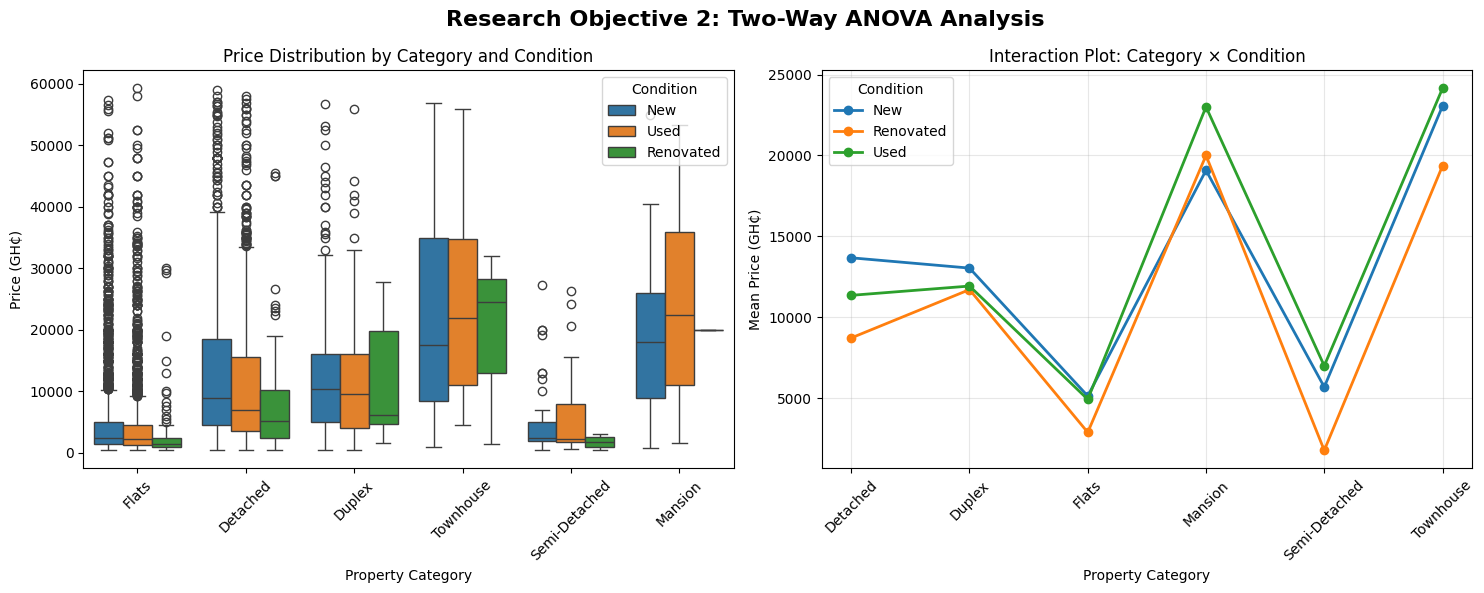

In [95]:
#Two-way ANOVA Analysis to determine the influence of categorial features on price
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings

warnings.filterwarnings('ignore')

anova_dataframe = sampl_data[['price', 'condition', 'category']].copy()
model = ols('price ~ C(condition) + C(category) + C(condition):C(category)', data=anova_dataframe).fit()
anova_table = anova_lm(model, typ=2)

print(anova_table)

print("\nPost-hoc Tests (Tukey HSD):")
print("\n--- Condition ---")

tukey_condition = pairwise_tukeyhsd(endog=anova_dataframe['price'], groups=anova_dataframe['condition'], alpha=0.05)
print(tukey_condition)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Research Objective 2: Two-Way ANOVA Analysis', fontsize=16, fontweight='bold')

# Grouped box plot
sns.boxplot(data=anova_dataframe, x='category', y='price', hue='condition', ax=axes[0])
axes[0].set_title('Price Distribution by Category and Condition')
axes[0].set_xlabel('Property Category')
axes[0].set_ylabel('Price (GH₵)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Condition')

# Interaction plot
interaction_data = anova_dataframe.groupby(['category', 'condition'])['price'].mean().reset_index()
for condition in interaction_data['condition'].unique():
    subset = interaction_data[interaction_data['condition'] == condition]
    axes[1].plot(subset['category'], subset['price'], marker='o', label=condition, linewidth=2)
    
axes[1].set_title('Interaction Plot: Category × Condition')
axes[1].set_xlabel('Property Category')
axes[1].set_ylabel('Mean Price (GH₵)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Condition')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('objective2_anova.png', dpi=300, bbox_inches='tight')
print("\n✓ ANOVA analysis saved as 'objective2_anova.png'")


## Research Objective 3: Location-Based Rental Price Patterns

### Research Question
Where are the most expensive and least expensive rental markets, and how do prices distribute geographically?

The analysis examines average rental price by locality and visualizes spatial patterns using:

- A **bar chart (Top 10 Localities by Average Rental Price)** of the top 10 localities by average price.

- A **geographic scatter plot (Geographic Distribution of Rental Prices)** using latitude and longitude to reveal spatial clusters of high and low rents.

**Statistical method:** Grouped summary statistics (mean/median) and spatial visualization.


In [1]:
print("RESEARCH OBJECTIVE 3: Locality Premiums and Amenities")

# Calculate average price by locality
locality_stats = sampl_data.groupby('locality').agg({
    'price': ['mean', 'median', 'count']
}).round(2)
locality_stats.columns = ['Mean_Price', 'Median_Price', 'Count']
locality_stats = locality_stats.sort_values('Mean_Price', ascending=False)

print("\nTop 10 Localities by Average Price:")
print(locality_stats.head(10))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Research Objective 3: Locality Price Analysis', fontsize=16, fontweight='bold')

# Top 10 localities
top10 = locality_stats.head(10)
axes[0].barh(range(len(top10)), top10['Mean_Price'], color='teal')
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels(top10.index)
axes[0].set_xlabel('Average Price (GH₵)')
axes[0].set_title('Top 10 Localities by Average Rental Price')
axes[0].invert_yaxis()

# Geographic scatter
scatter = axes[1].scatter(sampl_data['lng'], sampl_data['lat'], c=sampl_data['price'], s=sampl_data['price']/50, 
                          cmap='YlOrRd', alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title('Geographic Distribution of Rental Prices')
plt.colorbar(scatter, ax=axes[1], label='Price (GH₵)')

plt.tight_layout()

RESEARCH OBJECTIVE 3: Locality Premiums and Amenities


NameError: name 'sampl_data' is not defined

## Research Objective 4: Space Efficiency Across Property Categories

### Research Question
How does rental price per square unit vary across property categories, and are these differences statistically significant?

We calculate **price per square unit** and compare categories using:

- **Shapiro-Wilk tests** for normality within each category.
- A **Kruskal-Wallis nonparametric test** (since normality is often violated) to assess if median efficiency differs by category.


The plots show:✅ **Statistical method:** **Kruskal-Wallis** (non-parametric) test with normality checks.



- **Violin plot (Distribution of Price Efficiency by Category):** Distribution shape and spread for each property category.- **Box plot (Price Efficiency Comparison):** Median and interquartile range differences across categories.

OBJECTIVE 4: Property Size Efficiency Analysis

Price per Square Unit by Category:
                mean  median    std  count
category                                  
Detached       71.92   47.14  72.29   1715
Duplex         38.55   14.88  56.75    278
Flats          43.27   18.00  60.42   4396
Mansion        83.92   32.67  90.77     49
Semi-Detached  37.95   17.31  57.54     57
Townhouse      87.16   68.88  72.46    132

Shapiro-Wilk Normality Test by Category:
Flats: W=0.7068, p=0.0000
Detached: W=0.8551, p=0.0000
Duplex: W=0.6512, p=0.0000
Townhouse: W=0.8852, p=0.0000
Semi-Detached: W=0.6369, p=0.0000
Mansion: W=0.8055, p=0.0000

Kruskal-Wallis H-test: H=402.1835, p=0.0000


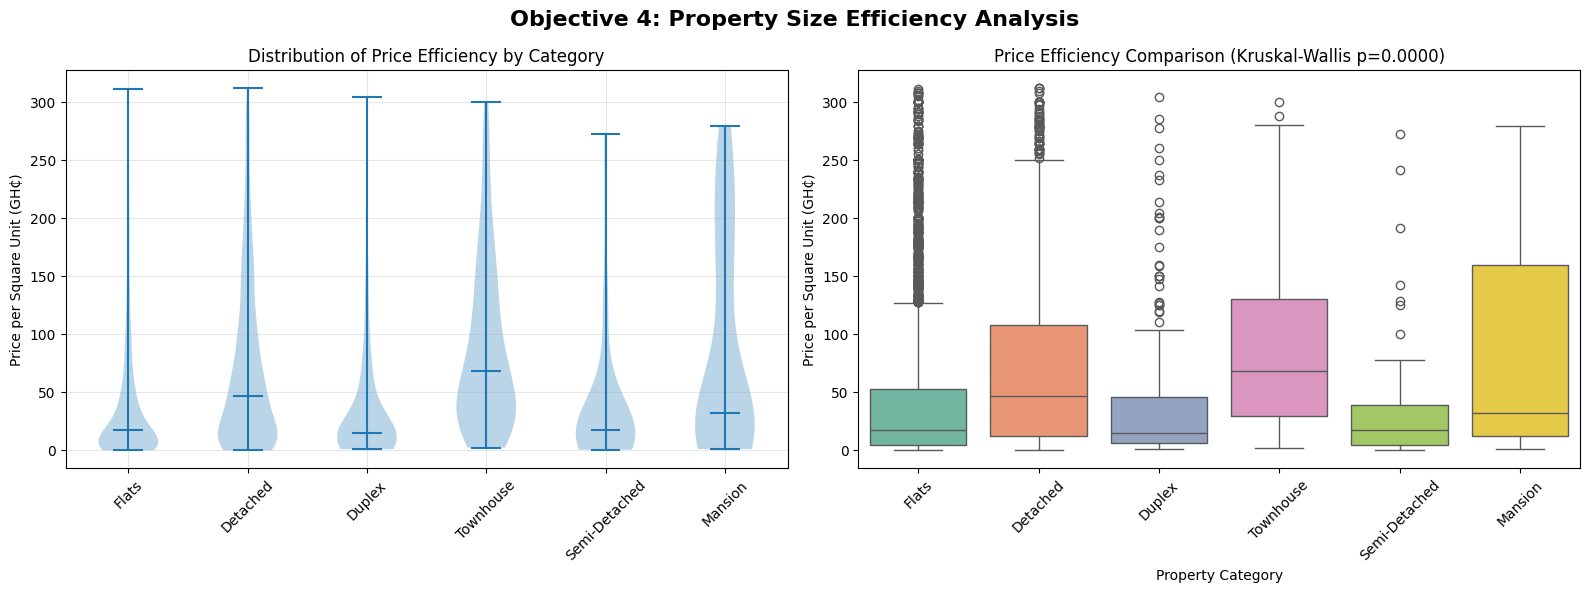

In [ ]:
print("OBJECTIVE 4: Property Size Efficiency Analysis")
print("="*80)

from scipy import stats

# Create price per square unit variable
sampl_data['price_per_sqft'] = sampl_data['price'] / sampl_data['floor_area']

# Remove outliers (infinite or extremely high values)
df_efficiency = sampl_data[sampl_data['price_per_sqft'].notna() & (sampl_data['price_per_sqft'] < sampl_data['price_per_sqft'].quantile(0.95))].copy()

print("\nPrice per Square Unit by Category:")
efficiency_stats = df_efficiency.groupby('category')['price_per_sqft'].agg(['mean', 'median', 'std', 'count'])
print(efficiency_stats.round(2))

# Test normality
print("\nShapiro-Wilk Normality Test by Category:")
for cat in df_efficiency['category'].unique():
    subset = df_efficiency[df_efficiency['category'] == cat]['price_per_sqft'].dropna()
    if len(subset) >= 3:
        stat, p = stats.shapiro(subset)
        print(f"{cat}: W={stat:.4f}, p={p:.4f}")

# Kruskal-Wallis test (non-parametric)
groups = [df_efficiency[df_efficiency['category'] == cat]['price_per_sqft'].dropna() 
          for cat in df_efficiency['category'].unique()]
h_stat, p_value = stats.kruskal(*groups)
print(f"\nKruskal-Wallis H-test: H={h_stat:.4f}, p={p_value:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Objective 4: Property Size Efficiency Analysis', fontsize=16, fontweight='bold')

# Violin plot
parts = axes[0].violinplot([df_efficiency[df_efficiency['category'] == cat]['price_per_sqft'].dropna().values 
                             for cat in df_efficiency['category'].unique()],
                            positions=range(len(df_efficiency['category'].unique())),
                            showmedians=True, showextrema=True)
axes[0].set_xticks(range(len(df_efficiency['category'].unique())))
axes[0].set_xticklabels(df_efficiency['category'].unique(), rotation=45)
axes[0].set_ylabel('Price per Square Unit (GH₵)')
axes[0].set_title('Distribution of Price Efficiency by Category')
axes[0].grid(True, alpha=0.3)

# Box plot comparison
sns.boxplot(data=df_efficiency, x='category', y='price_per_sqft', ax=axes[1], palette='Set2')
axes[1].set_xlabel('Property Category')
axes[1].set_ylabel('Price per Square Unit (GH₵)')
axes[1].set_title(f'Price Efficiency Comparison (Kruskal-Wallis p={p_value:.4f})')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
# plt.savefig('objective6_size_efficiency.png', dpi=300, bbox_inches='tight')

## Research Objective 5: Furnishing Premium & Pricing Implications

### Research Question
What premium does furnishing confer on rental price, and how can this inform pricing strategy and development investment?

This section uses **ANCOVA** to quantify how furnishing level affects price while controlling for bedroom count (and their interaction). The charts show:

- **Bar chart (Average Price by Bedrooms and Furnishing Status):** How average rent changes across furnishing levels for each bedroom count.
- **Interaction plot (Furnishing x Bedrooms):** Whether the furnishing premium changes with unit size.

**Statistical method:** **ANCOVA** (analysis of covariance).

### Strategic Implications for Pricing & Development


- **Pricing:** Use the estimated premiums to set tiered rents based on furnishing level and unit size.- **Market positioning:** Highlight high-value localities and property categories where rent per square meter is strongest.
- **Development:** Prioritize upgrades (e.g., furnishing packages) for property types where the premium is largest.

OBJECTIVE 5: Furnishing Premium Analysis

Average Price by Bedrooms and Furnishing Status:
                           mean  count       std
bedrooms is_furnished                           
1        0              1311.55   1059   1044.14
         1              1924.89    332   2710.37
         2             10872.19    209   9103.72
2        0              3169.23   1500   3075.95
         1              4161.95    720   3255.21
         2             15812.48    330  11429.99
3        0              7375.27    850   7535.22
         1              8387.14    521   7736.87
         2             20898.09    221  14341.80
4        0             14950.89    429  11940.88
         1             14609.27    336  10935.87
         2             28094.25    105  16104.03
5        0             19162.65    132  15584.97
         1             18491.66    101  14450.27
         2             32473.62     32  14792.60
6        0             17809.78     32  13452.28
         1             1522

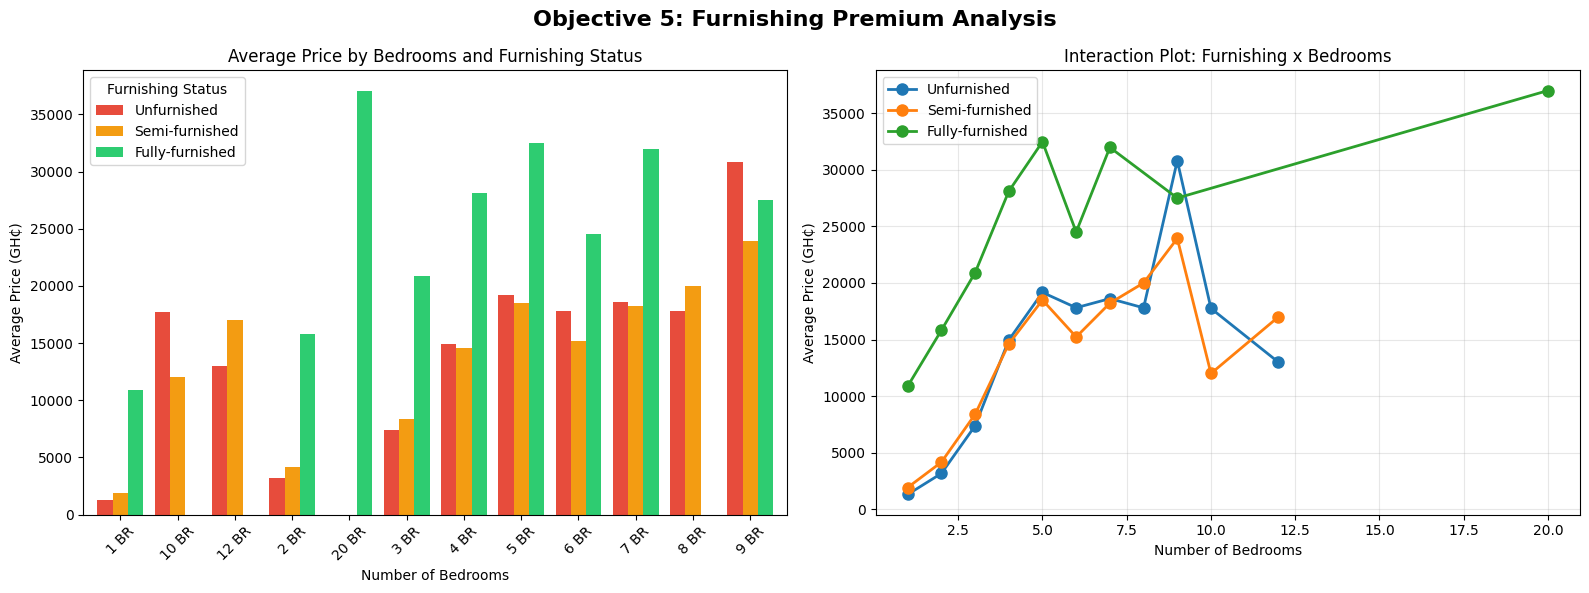

In [ ]:
print("OBJECTIVE 5: Furnishing Premium Analysis")

# Prepare data
furnish_df = sampl_data[['price', 'is_furnished', 'bedrooms']].copy()
furnish_df['bedrooms_cat'] = furnish_df['bedrooms'].astype(str) + ' BR'

# Calculate mean prices
furnish_stats = furnish_df.groupby(['bedrooms', 'is_furnished'])['price'].agg(['mean', 'count', 'std'])
print("\nAverage Price by Bedrooms and Furnishing Status:")
print(furnish_stats.round(2))

# Calculate premium percentages (relative to unfurnished)
print("\nFurnishing Premium (%):")
for br in sorted(furnish_df['bedrooms'].unique()):
    unfurnished_price = furnish_df[(furnish_df['bedrooms'] == br) & (furnish_df['is_furnished'] == 0)]['price'].mean()
    if not np.isnan(unfurnished_price):
        for furn in [1, 2]:
            furnished_price = furnish_df[(furnish_df['bedrooms'] == br) & (furnish_df['is_furnished'] == furn)]['price'].mean()
            if not np.isnan(furnished_price):
                premium = ((furnished_price - unfurnished_price) / unfurnished_price) * 100
                furn_label = "Semi-furnished" if furn == 1 else "Fully-furnished"
                print(f"{br} BR - {furn_label}: {premium:+.1f}%")

# ANCOVA
formula = 'price ~ C(is_furnished) + bedrooms + C(is_furnished):bedrooms'
model = ols(formula, data=furnish_df).fit()
print("\nANCOVA Results:")
print(anova_lm(model, typ=2))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Objective 5: Furnishing Premium Analysis', fontsize=16, fontweight='bold')

# Grouped bar chart
furnish_means = furnish_df.groupby(['bedrooms_cat', 'is_furnished'])['price'].mean().reset_index()
furnish_pivot = furnish_means.pivot(index='bedrooms_cat', columns='is_furnished', values='price')
furnish_pivot.plot(kind='bar', ax=axes[0], width=0.8, color=['#e74c3c', '#f39c12', '#2ecc71'])
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Average Price (GH₵)')
axes[0].set_title('Average Price by Bedrooms and Furnishing Status')
axes[0].legend(['Unfurnished', 'Semi-furnished', 'Fully-furnished'], title='Furnishing Status')
axes[0].tick_params(axis='x', rotation=45)

# Interaction plot
for furn in sorted(furnish_df['is_furnished'].unique()):
    subset = furnish_df[furnish_df['is_furnished'] == furn].groupby('bedrooms')['price'].mean()
    furn_label = ['Unfurnished', 'Semi-furnished', 'Fully-furnished'][int(furn)]
    axes[1].plot(subset.index, subset.values, marker='o', linewidth=2, markersize=8, label=furn_label)

axes[1].set_xlabel('Number of Bedrooms')
axes[1].set_ylabel('Average Price (GH₵)')
axes[1].set_title('Interaction Plot: Furnishing x Bedrooms')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('objective9_furnishing_premium.png', dpi=300, bbox_inches='tight')

In [ ]:
import folium
from folium.plugins import HeatMap

# Use the sampled dataset for geographic visualization
df = sampled_data.copy()

# 1) Initialize the map: center on the dataset median coordinate (a robust central point)
#    and use a clean tile style for readability.
m = folium.Map(location=[df['lat'].median(), df['lng'].median()], 
               zoom_start=8, 
               tiles='CartoDB positron')

# 2) Prepare the heatmap data: each entry is [lat, lon, weight].
#    We set weight = price so that higher-priced listings appear as hotter spots.
heat_data = df[['lat', 'lng', 'price']].dropna().values.tolist()

# 3) Add the heatmap layer to the map.
#    Adjust radius/blur to tune the visual spread of hot spots.
HeatMap(heat_data, 
        radius=15,          # Size of the heat points
        blur=10,            # Smoothness of the heat transition
        max_zoom=1          # Keep the heatmap stable across zoom levels
       ).add_to(m)

# 4) Rendering: returning `m` in a Jupyter cell will display the interactive map.
m

## Geographic Price Heatmap Interpretation

This heatmap shows where rental prices are concentrated geographically:

- Hotter (brighter) areas indicate neighborhoods with **higher average rental prices**.
- Cooler areas indicate **lower-priced rental zones**.

The map helps identify **pricing clusters**, which can inform decisions about where to focus marketing, invest in property improvements, or target pricing strategies.